# Week 5–6 · Anomaly Detection
## Isolation Forest · One-Class SVM · Autoencoder — Bearing Fault Detection

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Why Anomaly Detection in Industrial IoT?

In predictive maintenance, **failure labels are expensive or unavailable**:
- Machines rarely fail during observation periods
- Operators may not log exact failure timestamps
- New failure modes are unknown a priori (zero-shot faults)

Anomaly detection learns the distribution of **normal behaviour** and flags deviations — no failure labels required.

### Methods Compared
| Method | Type | Complexity | Interpretability |
|--------|------|------------|------------------|
| Isolation Forest | Tree-based | $O(n \log n)$ | Medium (isolation depth) |
| One-Class SVM | Kernel | $O(n^2)$–$O(n^3)$ | Low (kernel trick) |
| Autoencoder | Neural | $O(n \cdot d)$ | Low (reconstruction error) |

### Dataset: CWRU Bearing (Synthetic)
Training: 800 normal samples | Test: 200 normal + 50 faults each class

In [1]:
# !pip install numpy pandas scikit-learn matplotlib seaborn tensorflow  # or torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

try:
    import tensorflow as tf
    from tensorflow import keras
    TF_AVAILABLE = True
    print(f'TensorFlow {tf.__version__} available.')
except ImportError:
    TF_AVAILABLE = False
    print('TensorFlow not installed. Autoencoder will use sklearn PCA-based approximation.')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'normal': '#2196F3', 'anomaly': '#FF5722'}
print('Libraries loaded.')

TensorFlow 2.20.0 available.
Libraries loaded.


In [3]:
def make_normal_bearings(n, seed=0):
    rng = np.random.default_rng(seed)
    rms   = rng.normal(0.10, 0.008, n)
    peak  = rng.normal(0.30, 0.020, n)
    kurt  = rng.normal(3.0,  0.20,  n)
    crest = rng.normal(3.0,  0.25,  n)
    temp  = rng.normal(55,   2,     n)
    rpm   = rng.normal(1500, 30,    n)
    return np.column_stack([rms, peak, kurt, crest, temp, rpm])

def make_faulty_bearings(n, fault_type='inner', seed=42):
    rng = np.random.default_rng(seed)
    shifts = {
        'inner': {'rms': 0.35, 'peak': 1.2, 'kurt': 6.5, 'crest': 5.5, 'temp': 70, 'rpm': 1480},
        'outer': {'rms': 0.28, 'peak': 0.95, 'kurt': 5.2, 'crest': 4.8, 'temp': 65, 'rpm': 1490},
        'ball':  {'rms': 0.22, 'peak': 0.75, 'kurt': 4.8, 'crest': 4.2, 'temp': 62, 'rpm': 1495},
    }
    s = shifts[fault_type]
    return np.column_stack([
        rng.normal(s['rms'],   0.03, n),
        rng.normal(s['peak'],  0.10, n),
        rng.normal(s['kurt'],  0.50, n),
        rng.normal(s['crest'], 0.40, n),
        rng.normal(s['temp'],  2.5,  n),
        rng.normal(s['rpm'],   25,   n),
    ])

FEATURES = ['rms', 'peak_to_peak', 'kurtosis', 'crest_factor', 'temperature', 'rpm']

X_normal_train = make_normal_bearings(800, seed=0)
X_normal_test  = make_normal_bearings(200, seed=1)
X_inner  = make_faulty_bearings(50, 'inner', 10)
X_outer  = make_faulty_bearings(50, 'outer', 20)
X_ball   = make_faulty_bearings(50, 'ball',  30)

X_test = np.vstack([X_normal_test, X_inner, X_outer, X_ball])
y_test = np.array([0]*200 + [1]*50 + [1]*50 + [1]*50)  # 0=normal, 1=anomaly

scaler = StandardScaler().fit(X_normal_train)
X_train_s = scaler.transform(X_normal_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_normal_train.shape} (all normal)')
print(f'Test:  {X_test.shape}  |  anomaly rate: {y_test.mean()*100:.1f}%')

Train: (800, 6) (all normal)
Test:  (350, 6)  |  anomaly rate: 42.9%


## 1 · Isolation Forest

### Mathematical Foundation

Isolation Forest (Liu et al., 2008) exploits the fact that **anomalies are few and different** — they require fewer splits to isolate.

For a point $\mathbf{x}$, the expected isolation depth $h(\mathbf{x})$ across $T$ trees gives the anomaly score:

$$s(\mathbf{x}, n) = 2^{-\dfrac{\mathbb{E}[h(\mathbf{x})]}{c(n)}}$$

where $c(n) = 2H(n-1) - \frac{2(n-1)}{n}$ is the expected path length of an unsuccessful BST search ($H$ = harmonic number).

- $s \approx 1$ → anomaly (isolated quickly)
- $s \approx 0.5$ → normal (hard to isolate)

**Time complexity**: $O(T \cdot \psi \log \psi)$ where $\psi$ is the subsample size (default 256).  
Independent of $n$ for large datasets — highly scalable for IoT streams.

In [4]:
iso = IsolationForest(n_estimators=200, contamination=0.1, max_samples=256, random_state=42)
iso.fit(X_train_s)

iso_scores = -iso.score_samples(X_test_s)  # higher score = more anomalous
iso_labels = (iso.predict(X_test_s) == -1).astype(int)

auc_iso = roc_auc_score(y_test, iso_scores)
print('Isolation Forest')
print(f'  ROC-AUC: {auc_iso:.4f}')
print(classification_report(y_test, iso_labels, target_names=['Normal', 'Anomaly']))

Isolation Forest
  ROC-AUC: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95       200
     Anomaly       0.88      1.00      0.94       150

    accuracy                           0.94       350
   macro avg       0.94      0.95      0.94       350
weighted avg       0.95      0.94      0.94       350



## 2 · One-Class SVM

### Mathematical Foundation

One-Class SVM (Schölkopf et al., 2001) finds the smallest hypersphere in feature space enclosing most normal data:

$$\min_{R, \mathbf{c}, \xi} R^2 + \frac{1}{\nu n} \sum_i \xi_i \quad \text{subject to} \quad \|\phi(\mathbf{x}_i) - \mathbf{c}\|^2 \leq R^2 + \xi_i, \; \xi_i \geq 0$$

With RBF kernel $K(\mathbf{x}, \mathbf{x'}) = \exp\!\left(-\gamma \|\mathbf{x} - \mathbf{x'}\|^2\right)$:

A point $\mathbf{x}$ is classified as anomaly if:
$$f(\mathbf{x}) = \sum_i \alpha_i K(\mathbf{x}_i, \mathbf{x}) - \rho < 0$$

**Hyperparameter $\nu$**: upper bound on the fraction of outliers in training (controls sensitivity).

In [5]:
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_train_s)

ocsvm_scores = -ocsvm.decision_function(X_test_s)
ocsvm_labels = (ocsvm.predict(X_test_s) == -1).astype(int)

auc_ocsvm = roc_auc_score(y_test, ocsvm_scores)
print('One-Class SVM')
print(f'  ROC-AUC: {auc_ocsvm:.4f}')
print(classification_report(y_test, ocsvm_labels, target_names=['Normal', 'Anomaly']))

One-Class SVM
  ROC-AUC: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94       200
     Anomaly       0.87      1.00      0.93       150

    accuracy                           0.94       350
   macro avg       0.94      0.95      0.94       350
weighted avg       0.95      0.94      0.94       350



## 3 · Autoencoder

### Architecture and Loss Function

An autoencoder learns a compressed representation (bottleneck) by minimising **reconstruction error**:

$$\mathcal{L}_{\text{AE}} = \frac{1}{n} \sum_{i=1}^{n} \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|_2^2$$

**Architecture** (encoder → bottleneck → decoder):
```
Input(6) → Dense(32, ReLU) → Dense(16, ReLU) → Dense(8, ReLU)  [encoder]
         → Dense(16, ReLU) → Dense(32, ReLU) → Dense(6, Linear) [decoder]
```

Trained exclusively on **normal** data. At inference time:
- Normal samples → low reconstruction error (learned manifold)
- Anomalies → high reconstruction error (out-of-distribution)

**Threshold $\tau$**: set at the 95th percentile of training reconstruction errors.

Model: "AE_Bearing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,774 (6.93 KB)

 Trainable params: 1,774 (6.93 KB)

 Non-trainable params: 0 (0.00 B)

Autoencoder | threshold τ = 0.008722
  ROC-AUC: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.94       200
     Anomaly       0.88      1.00      0.93       150

    accuracy                           0.94       350
   macro avg       0.94      0.95      0.94       350
weighted avg       0.95      0.94      0.94       350



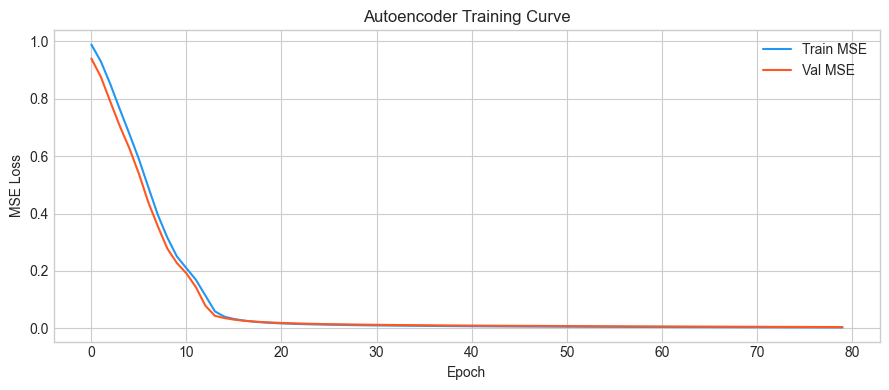

In [6]:
if TF_AVAILABLE:
    tf.random.set_seed(42)
    d = X_train_s.shape[1]

    inputs = keras.Input(shape=(d,))
    x = keras.layers.Dense(32, activation='relu')(inputs)
    x = keras.layers.Dense(16, activation='relu')(x)
    x = keras.layers.Dense(8,  activation='relu', name='bottleneck')(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    outputs = keras.layers.Dense(d, activation='linear')(x)

    autoencoder = keras.Model(inputs, outputs, name='AE_Bearing')
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    autoencoder.summary()

    history = autoencoder.fit(
        X_train_s, X_train_s,
        epochs=80, batch_size=32,
        validation_split=0.15,
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0
    )

    X_recon_test = autoencoder.predict(X_test_s, verbose=0)
    ae_errors = np.mean((X_test_s - X_recon_test)**2, axis=1)

    # Threshold: 95th percentile of training reconstruction error
    X_recon_train = autoencoder.predict(X_train_s, verbose=0)
    train_errors = np.mean((X_train_s - X_recon_train)**2, axis=1)
    tau = np.percentile(train_errors, 95)

    ae_labels = (ae_errors > tau).astype(int)
    auc_ae = roc_auc_score(y_test, ae_errors)

    print(f'Autoencoder | threshold τ = {tau:.6f}')
    print(f'  ROC-AUC: {auc_ae:.4f}')
    print(classification_report(y_test, ae_labels, target_names=['Normal', 'Anomaly']))

    # Loss curve
    plt.figure(figsize=(9, 4))
    plt.plot(history.history['loss'], label='Train MSE', color='#2196F3')
    plt.plot(history.history['val_loss'], label='Val MSE', color='#FF5722')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title('Autoencoder Training Curve')
    plt.legend(); plt.tight_layout()
    plt.savefig('plots/07_ae_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('TensorFlow not available. Using PCA reconstruction error as AE proxy.')
    pca = PCA(n_components=3).fit(X_train_s)
    X_recon = pca.inverse_transform(pca.transform(X_test_s))
    ae_errors = np.mean((X_test_s - X_recon)**2, axis=1)
    train_recon = pca.inverse_transform(pca.transform(X_train_s))
    train_errors = np.mean((X_train_s - train_recon)**2, axis=1)
    tau = np.percentile(train_errors, 95)
    ae_labels = (ae_errors > tau).astype(int)
    auc_ae = roc_auc_score(y_test, ae_errors)
    print(f'PCA proxy | τ = {tau:.6f} | ROC-AUC: {auc_ae:.4f}')
    print(classification_report(y_test, ae_labels, target_names=['Normal', 'Anomaly']))

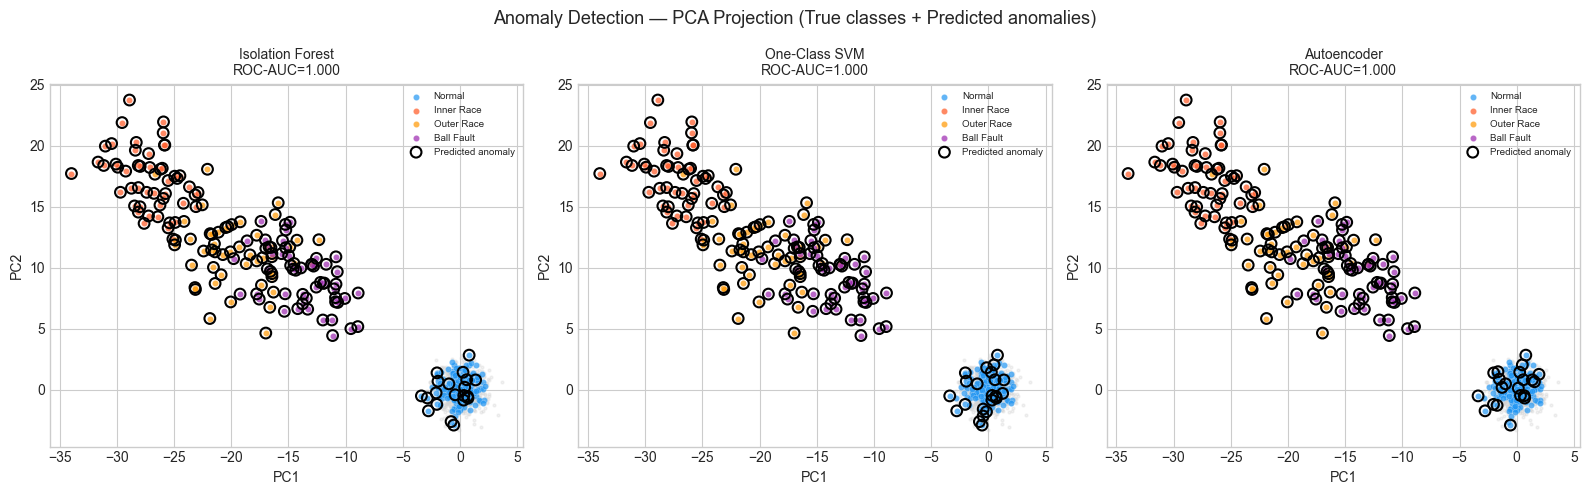

In [7]:
# PCA 2D projection for visualization
pca_vis = PCA(n_components=2).fit(X_train_s)
Z_train = pca_vis.transform(X_train_s)
Z_test  = pca_vis.transform(X_test_s)

labels_str = np.array(['Normal']*200 + ['Inner Race']*50 + ['Outer Race']*50 + ['Ball Fault']*50)
colors_map = {'Normal': '#2196F3', 'Inner Race': '#FF5722', 'Outer Race': '#FF9800', 'Ball Fault': '#9C27B0'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Isolation Forest', 'One-Class SVM', 'Autoencoder']
all_preds = [iso_labels, ocsvm_labels, ae_labels]

for ax, title, preds in zip(axes, titles, all_preds):
    # True class coloring
    for cls, color in colors_map.items():
        mask = labels_str == cls
        ax.scatter(Z_test[mask, 0], Z_test[mask, 1], c=color, s=20, alpha=0.7,
                   label=cls, edgecolors='white', linewidth=0.2)
    # Mark predicted anomalies with black ring
    anomaly_mask = preds == 1
    ax.scatter(Z_test[anomaly_mask, 0], Z_test[anomaly_mask, 1],
               s=60, facecolors='none', edgecolors='black', linewidth=1.5, label='Predicted anomaly')
    ax.set_title(f'{title}\nROC-AUC={roc_auc_score(y_test, [iso_scores, ocsvm_scores, ae_errors][titles.index(title)]):.3f}', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Training normal cloud
for ax in axes:
    ax.scatter(Z_train[:, 0], Z_train[:, 1], c='lightgrey', s=4, alpha=0.3, zorder=0, label='Train normal')

plt.suptitle('Anomaly Detection — PCA Projection (True classes + Predicted anomalies)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/07_anomaly_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

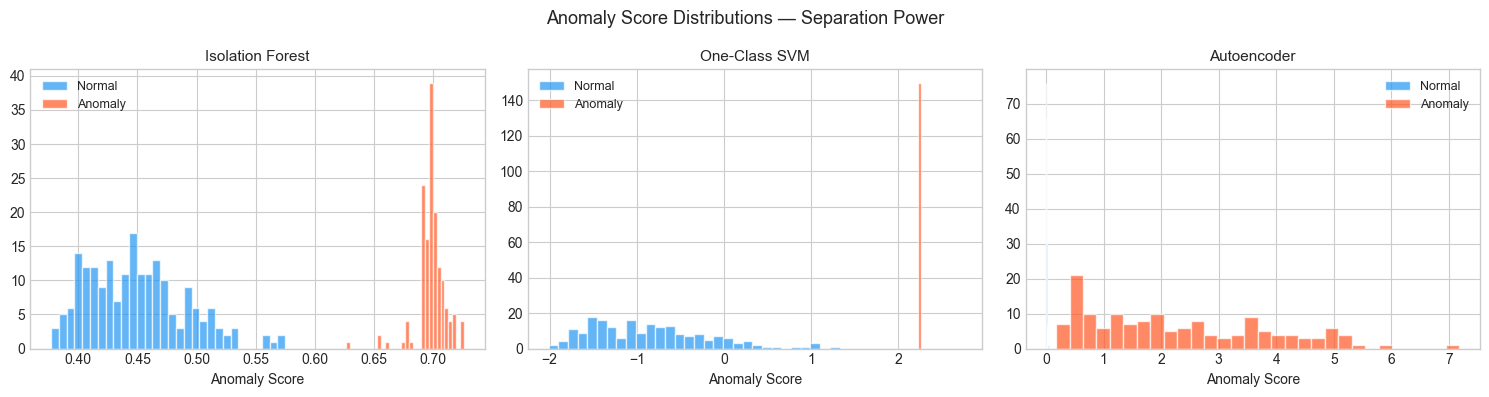

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
score_data = [
    ('Isolation Forest', iso_scores),
    ('One-Class SVM', ocsvm_scores),
    ('Autoencoder', ae_errors),
]
for ax, (name, scores) in zip(axes, score_data):
    ax.hist(scores[y_test == 0], bins=30, alpha=0.7, color=COLORS['normal'], label='Normal', edgecolor='white')
    ax.hist(scores[y_test == 1], bins=30, alpha=0.7, color=COLORS['anomaly'], label='Anomaly', edgecolor='white')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Anomaly Score')
    ax.legend(fontsize=9)

plt.suptitle('Anomaly Score Distributions — Separation Power', fontsize=13)
plt.tight_layout()
plt.savefig('plots/07_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Discussion

### Loss Function Analysis (Autoencoder)

The MSE reconstruction loss $\|\mathbf{x} - \hat{\mathbf{x}}\|_2^2$ has a key property:  
it penalises **large deviations** quadratically, making it sensitive to the impulsive anomalies typical in bearing faults (high kurtosis, high crest factor).

Alternative losses:
- **MAE** ($L_1$): more robust to outliers but misses subtle drift
- **Huber**: smooth compromise between MSE and MAE
- **Contrastive/Triplet** (advanced): requires some labelled anomaly examples

### Method Comparison

| Method | Strength | Weakness | Best for |
|--------|----------|----------|----------|
| Isolation Forest | Fast, scalable, no tuning | Struggles with high dimensions | Real-time IoT streams |
| One-Class SVM | Theoretically grounded | Slow on large data | Low-frequency, offline |
| Autoencoder | Captures complex distributions | Needs more data + tuning | High-dimensional sensor arrays |

### HAIIP Production
The HAIIP system uses `IsolationForest` as the primary detector (`haiip/core/anomaly.py`),  
with SHAP-based explanation of which feature contributed most to the anomaly score.

→ **Week 7–8**: Time series — sequential patterns contain more predictive information than point-in-time snapshots.